# Análisis de Datos — TP Integrador
### FIUBA · CEIA · Análisis de Datos 3B 2026

**Dataset:** Chicago Crimes 2015 (portal de datos abiertos de Chicago, API Socrata)
**Problema de ML planteado:** Clasificación binaria — predecir `Arrest` (¿hubo arresto o no?) a partir de las características del incidente (tipo de crimen, ubicación, horario, etc.)

**Estructura del notebook:**
1. Carga y exploración de los datos
2. Visualización
3. Definición del problema de ML supervisado
4. Preprocesamiento y limpieza
5. Feature engineering
6. Reducción de dimensionalidad
7. Conclusiones (para la presentación)


In [ ]:
import os
import math
import scipy.stats
import missingno as msno
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("figs", exist_ok=True)

RANDOM_STATE = 42

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 1. Carga y exploración de los datos

Descargamos el dataset desde la API de Socrata (portal de datos abiertos de la ciudad de Chicago) y hacemos una primera inspección: shape, tipos de datos, y una lectura conceptual de qué representa cada variable.

In [ ]:
# Descarga directa desde la API de Socrata
url = 'https://data.cityofchicago.org/resource/vwwp-7yr9.csv?$limit=400000'

try:
    df = pd.read_csv(url)
    print('Datos cargados correctamente desde la API.')
except Exception as e:
    print('No se pudo descargar desde la API:', e)
    print('Puedes descargar el CSV manualmente desde el portal de Chicago.')

Datos cargados correctamente desde la API.


In [ ]:
# Descarga directa desde la API asociada a la variable IUCR
url2 = 'https://data.cityofchicago.org/resource/c7ck-438e.csv?$limit=400000'

try:
    df_auxiliar_IUCR = pd.read_csv(url2)
    print('Datos cargados correctamente desde la API.')
except Exception as e:
    print('No se pudo descargar desde la API:', e)
    print('Puedes descargar el CSV manualmente desde el portal de Chicago.')

Datos cargados correctamente desde la API.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264905 entries, 0 to 264904
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    264905 non-null  int64  
 1   case_number           264905 non-null  object 
 2   date                  264905 non-null  object 
 3   block                 264905 non-null  object 
 4   iucr                  264905 non-null  object 
 5   primary_type          264905 non-null  object 
 6   description           264905 non-null  object 
 7   location_description  264287 non-null  object 
 8   arrest                264905 non-null  bool   
 9   domestic              264905 non-null  bool   
 10  beat                  264905 non-null  int64  
 11  district              264905 non-null  int64  
 12  ward                  264903 non-null  float64
 13  community_area        264891 non-null  float64
 14  fbi_code              264905 non-null  object 
 15  

In [ ]:
# Normalizamos nombres de columnas (el endpoint Socrata las devuelve en minúscula)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

n_obs, n_vars = df.shape
print(f"Observaciones: {n_obs} | Variables: {n_vars}")
df.dtypes.value_counts()

Observaciones: 264905 | Variables: 22


,count
object,10
float64,6
int64,4
bool,2


In [ ]:
columnas_string = ['id','case_number','beat', 'district', 'community_area', 'ward']
df[columnas_string] = df[columnas_string].astype('string')

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['updated_on'] = pd.to_datetime(df['updated_on'], errors='coerce')

df.dtypes

,0
id,string[python]
case_number,string[python]
date,datetime64[ns]
block,object
iucr,object
primary_type,object
description,object
location_description,object
arrest,bool
domestic,bool


#### Clasificación conceptual de las variables

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

print(f'Variables cuantitativas según pandas ({len(num_cols)}):')
print(num_cols)

print(f'\nVariables categóricas/textuales según pandas ({len(cat_cols)}):')
print(cat_cols)

Variables cuantitativas según pandas (5):
['x_coordinate', 'y_coordinate', 'year', 'latitude', 'longitude']

Variables categóricas/textuales según pandas (15):
['id', 'case_number', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'location']


**Separación conceptual de variables** (para documentar en la presentación):

- **Categóricas nominales:** `primary_type`, `description`, `location_description`, `iucr`, `fbi_code`, `block`
- **Categóricas binarias:** `arrest` (target), `domestic`
- **Numéricas discretas / identificadores:** `beat`, `district`, `ward`, `community_area`, `id`, `case_number`
- **Numéricas continuas:** `latitude`, `longitude`, `x_coordinate`, `y_coordinate`
- **Temporal:** `date`

In [ ]:
# Valores faltantes
faltantes = df.isna().sum().sort_values(ascending=False)
pct_faltantes = (faltantes / len(df) * 100).round(2)
tabla_faltantes = pd.DataFrame({"faltantes": faltantes, "%": pct_faltantes})
tabla_faltantes = tabla_faltantes[tabla_faltantes["faltantes"] > 0]
tabla_faltantes

,faltantes,%
longitude,6996,2.64
x_coordinate,6996,2.64
location,6996,2.64
y_coordinate,6996,2.64
latitude,6996,2.64
location_description,618,0.23
community_area,14,0.01
ward,2,0.00


**Clasificación de los faltantes** (hipótesis a confirmar contra la tabla obtenida arriba):

- `latitude` / `longitude` / `x_coordinate` / `y_coordinate` / `location`: suelen faltar juntos → **MAR**, dependen de si el caso tuvo geocodificación exitosa, no del valor geográfico en sí.
- `ward` / `community_area`: a veces vacíos por carga incompleta en ciertos distritos → **MAR**.
- `case_number` / `location_description`: pocos nulos aislados y sin patrón aparente → posible **MCAR**.

*Completar con los porcentajes reales una vez ejecutado.*

In [ ]:
# Duplicados

print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

if 'id' in df.columns:
    print(f"IDs únicos: {df['id'].nunique()} de {len(df)} filas")

df = df.drop_duplicates()

Cantidad de filas duplicadas: 0
IDs únicos: 264905 de 264905 filas


#### Integridad y consistencia

In [ ]:
# Nulicidad
print(f"\nIDs nulos: {df['id'].isna().sum()}")
print(f"IDs duplicados: {df['id'].duplicated().sum()}")
print(f"Cantidad de IDs únicos: {df['id'].nunique()}")

# Fechas
print(f"\nFechas nulas: {df['date'].isna().sum()}")
print(f"Fecha mínima: {df['date'].min()}")
print(f"Fecha máxima: {df['date'].max()}")

fuera_2015 = df['date'].dt.year.ne(2015).sum()

print(f"Registros fuera de 2015: {fuera_2015}")

# Geograficos
print(f"\nLatitud nula: {df['latitude'].isna().sum()}")
print(f"Longitud nula: {df['longitude'].isna().sum()}")

solo_latitud = df['latitude'].notna() & df['longitude'].isna()
solo_longitud = df['latitude'].isna() & df['longitude'].notna()

print(f"Solo latitud: {solo_latitud.sum()}")
print(f"Solo longitud: {solo_longitud.sum()}")

print(f"Latitud nula: {df['latitude'].isna().sum()}")
print(f"Longitud nula: {df['longitude'].isna().sum()}")

solo_latitud = df['latitude'].notna() & df['longitude'].isna()
solo_longitud = df['latitude'].isna() & df['longitude'].notna()

print(f"Solo latitud: {solo_latitud.sum()}")
print(f"Solo longitud: {solo_longitud.sum()}")

# Binaras
print(f"\nValores de arrest:")
print(df['arrest'].value_counts(dropna=False))

print(f"\nValores de domestic:")
print(df['domestic'].value_counts(dropna=False))




IDs nulos: 0
IDs duplicados: 0
Cantidad de IDs únicos: 264905

Fechas nulas: 0
Fecha mínima: 2015-01-01 00:00:00
Fecha máxima: 2015-12-31 23:59:00
Registros fuera de 2015: 0

Latitud nula: 6996
Longitud nula: 6996
Solo latitud: 0
Solo longitud: 0
Latitud nula: 6996
Longitud nula: 6996
Solo latitud: 0
Solo longitud: 0

Valores de arrest:
arrest
False    194823
True      70082
Name: count, dtype: int64

Valores de domestic:
domestic
False    215893
True      49012
Name: count, dtype: int64


## 2. Visualización

Aplicamos el gráfico adecuado según el tipo de variable: distribución del target, variables categóricas, series temporales y distribución geográfica.

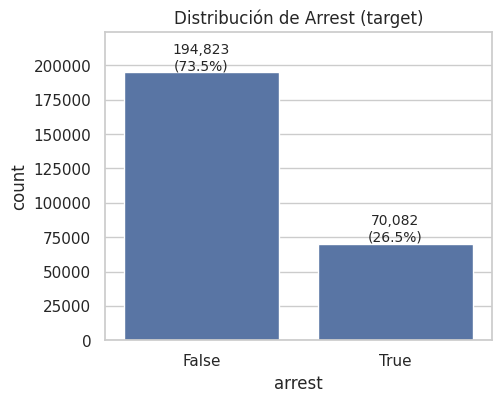

Balance de clases (Arrest):
arrest
False   73.54
True    26.46
Name: proportion, dtype: float64


In [ ]:
# 2.1 Distribución del target
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="arrest")

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

plt.title("Distribución de Arrest (target)")
plt.ylim(0, df["arrest"].value_counts().max() * 1.15)
plt.savefig("figs/01_distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

balance = df["arrest"].value_counts(normalize=True) * 100
print(f"Balance de clases (Arrest):\n{balance}")

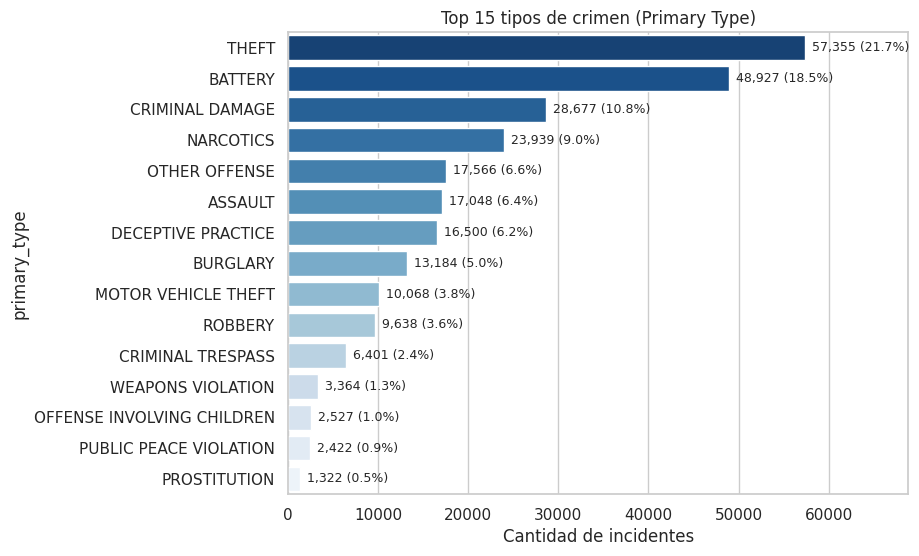

In [ ]:
# 2.2 Top tipos de crimen
plt.figure(figsize=(8, 6))
top_tipos = df["primary_type"].value_counts().head(15)
ax = sns.barplot(x=top_tipos.values, y=top_tipos.index, palette="Blues_r")

total = len(df)
for i, valor in enumerate(top_tipos.values):
    pct = valor / total * 100
    ax.annotate(f"{valor:,} ({pct:.1f}%)", (valor, i), ha="left", va="center",
                fontsize=9, xytext=(5, 0), textcoords="offset points")

plt.title("Top 15 tipos de crimen (Primary Type)")
plt.xlabel("Cantidad de incidentes")
plt.xlim(0, top_tipos.values.max() * 1.2)
plt.savefig("figs/02_top_tipos_crimen.png", dpi=150, bbox_inches="tight")
plt.show()

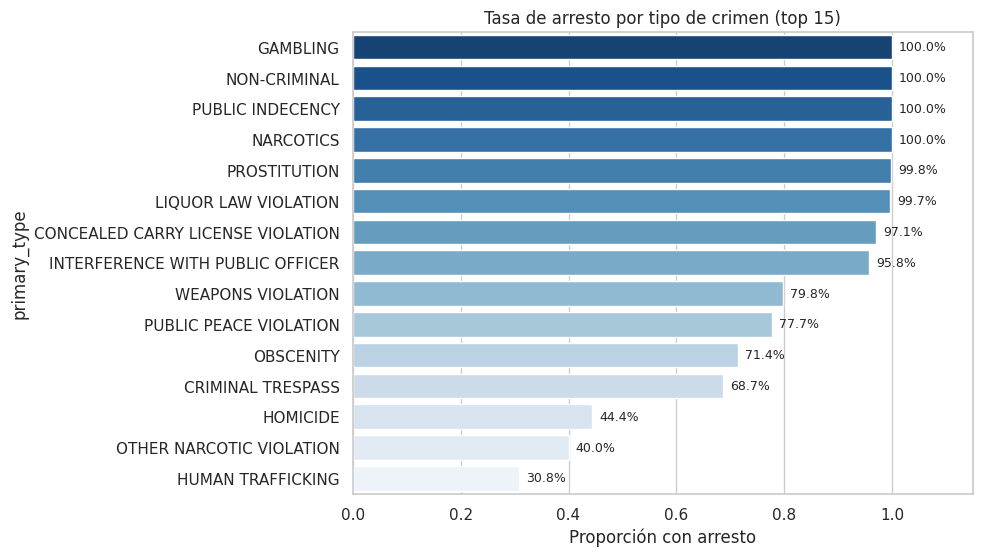

In [ ]:
# 2.3 Tasa de arresto por tipo de crimen (cruce categórica-target)
tasa_arresto_tipo = (
    df.groupby("primary_type")["arrest"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=tasa_arresto_tipo.values, y=tasa_arresto_tipo.index, palette="Blues_r")

for i, valor in enumerate(tasa_arresto_tipo.values):
    ax.annotate(f"{valor*100:.1f}%", (valor, i), ha="left", va="center",
                fontsize=9, xytext=(5, 0), textcoords="offset points")

plt.title("Tasa de arresto por tipo de crimen (top 15)")
plt.xlabel("Proporción con arresto")
plt.xlim(0, tasa_arresto_tipo.values.max() * 1.15)
plt.savefig("figs/03_tasa_arresto_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

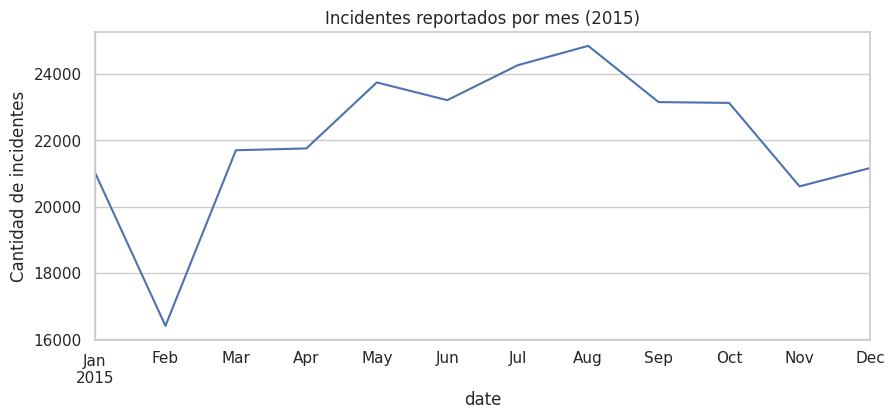

In [ ]:
# 2.4 Serie temporal: incidentes por mes
df["date"] = pd.to_datetime(df["date"], errors="coerce")
serie_mensual = df.set_index("date").resample("ME").size()
plt.figure(figsize=(10, 4))
serie_mensual.plot()
plt.title("Incidentes reportados por mes (2015)")
plt.ylabel("Cantidad de incidentes")
plt.savefig("figs/04_serie_temporal_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

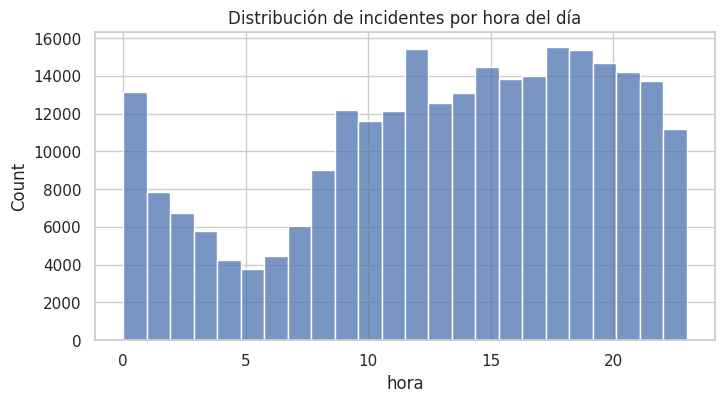

In [ ]:
# 2.5 Distribución horaria
df["hora"] = df["date"].dt.hour
plt.figure(figsize=(8, 4))
sns.histplot(df["hora"], bins=24, kde=False)
plt.title("Distribución de incidentes por hora del día")
plt.savefig("figs/05_distribucion_horaria.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
variables_numericas = df.select_dtypes(include='number').columns
variables_numericas.to_list()

## Selección de variables numéricas
variables_numericas = ['latitude', 'longitude', 'hora', 'mes']

df['mes'] = df['date'].dt.month

## Genero las medidas de tendencia central y dispersión para las variables numéricas (Valide antes que solo hubiera una moda para cada varaiable)
medidas_descriptivas = pd.DataFrame({
    'Media': df[variables_numericas].mean(),
    'Moda': df[variables_numericas].mode().iloc[0],
    'Mínimo': df[variables_numericas].min(),
    'Q1 (0.25)': df[variables_numericas].quantile(0.25),
    'Mediana - Q2 (0.50)': df[variables_numericas].quantile(0.50),
    'Q3 (0.75)': df[variables_numericas].quantile(0.75),
    'Rango Intercuartílico (IQR)': (df[variables_numericas].quantile(0.75) - df[variables_numericas].quantile(0.25)),
    'Máximo': df[variables_numericas].max(),
    'Desviación Estándar': df[variables_numericas].std(),
    'Varianza': df[variables_numericas].var(),
    'Curtosis': df[variables_numericas].kurtosis(),
    'Asimetría (Skewness)': df[variables_numericas].skew(),
    'MAD': (df[variables_numericas]- df[variables_numericas].median()).abs().median()
})

pd.set_option('display.float_format', '{:,.2f}'.format)

medidas_descriptivas

,Media,Moda,Mínimo,Q1 (0.25),Mediana - Q2 (0.50),Q3 (0.75),Rango Intercuartílico (IQR),Máximo,Desviación Estándar,Varianza,Curtosis,Asimetría (Skewness),MAD
latitude,41.84,41.88,41.64,41.77,41.86,41.90,0.14,42.02,0.09,0.01,-0.97,-0.05,0.07
longitude,-87.67,-87.63,-87.93,-87.72,-87.67,-87.63,0.09,-87.52,0.06,0.00,0.18,-0.29,0.04
hora,13.23,18.00,0.00,9.00,14.00,19.00,10.00,23.00,6.60,43.62,-0.77,-0.46,5.00
mes,6.61,8.00,1.00,4.00,7.00,9.00,5.00,12.00,3.35,11.22,-1.13,-0.05,3.00


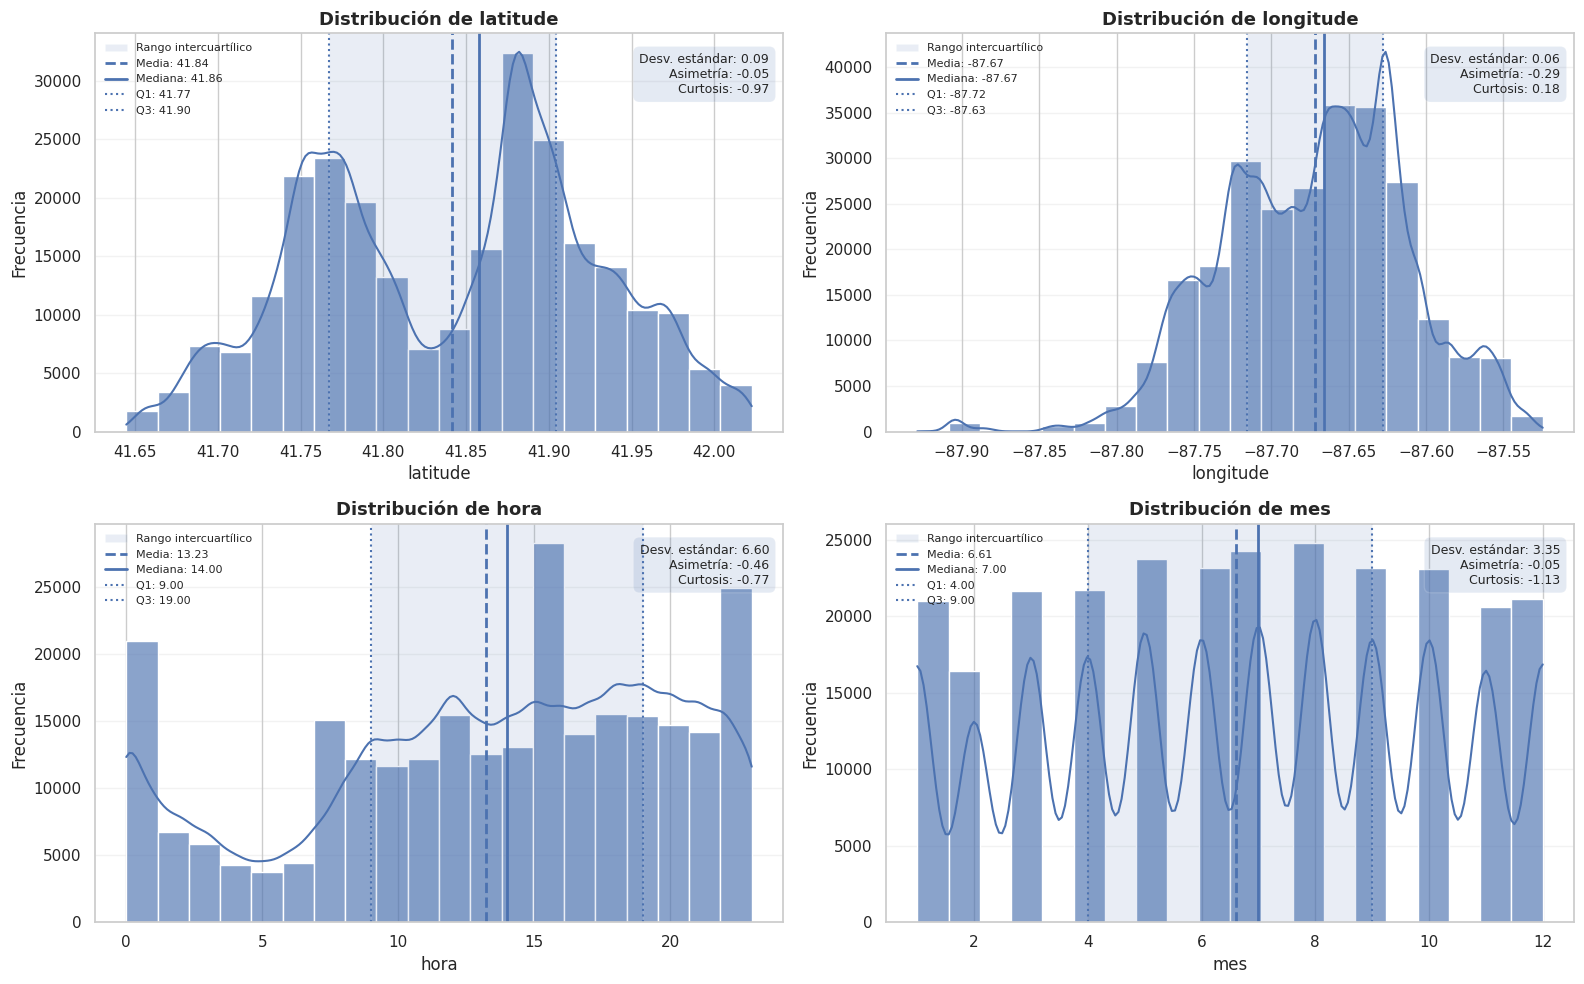

In [ ]:
# Cantidad de gráficos por fila
n_columnas = 2

# Cantidad de filas necesaria
n_filas = math.ceil(len(variables_numericas) / n_columnas)

# Crear figura
fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(16, 5 * n_filas)
)

# Convertir axes en una lista plana
axes = axes.flatten()

# Recorrer variables
for i, columna in enumerate(variables_numericas):

    ax = axes[i]

    # Eliminar valores nulos
    serie = df[columna].dropna()

    # Estadísticas
    media = serie.mean()
    mediana = serie.median()
    std = serie.std()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    asimetria = serie.skew()
    curtosis = serie.kurt()

    # Histograma + KDE
    sns.histplot(
        serie,
        bins=20,
        kde=False if columna in ['hour', 'month'] else True,
        alpha=0.65,
        edgecolor='white',
        ax=ax
    )

    # Rango intercuartílico
    ax.axvspan(
        q1,
        q3,
        alpha=0.12,
        label='Rango intercuartílico'
    )

    # Media
    ax.axvline(
        media,
        linestyle='--',
        linewidth=2,
        label=f'Media: {media:,.2f}'
    )

    # Mediana
    ax.axvline(
        mediana,
        linestyle='-',
        linewidth=2,
        label=f'Mediana: {mediana:,.2f}'
    )

    # Q1
    ax.axvline(
        q1,
        linestyle=':',
        linewidth=1.5,
        label=f'Q1: {q1:,.2f}'
    )

    # Q3
    ax.axvline(
        q3,
        linestyle=':',
        linewidth=1.5,
        label=f'Q3: {q3:,.2f}'
    )

    # Título
    ax.set_title(
        f'Distribución de {columna}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

    # Estadísticas adicionales
    texto = (
        f'Desv. estándar: {std:,.2f}\n'
        f'Asimetría: {asimetria:.2f}\n'
        f'Curtosis: {curtosis:.2f}'
    )

    ax.text(
        0.98,
        0.95,
        texto,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round,pad=0.5',
            alpha=0.15
        )
    )

    # Cuadrícula
    ax.grid(
        axis='y',
        alpha=0.25
    )

    # Leyenda
    ax.legend(
        frameon=False,
        fontsize=8
    )

# Eliminar espacios sobrantes
for j in range(len(variables_numericas), len(axes)):
    fig.delaxes(axes[j])

# Ajustar espacios
plt.tight_layout()

# Mostrar
plt.show()

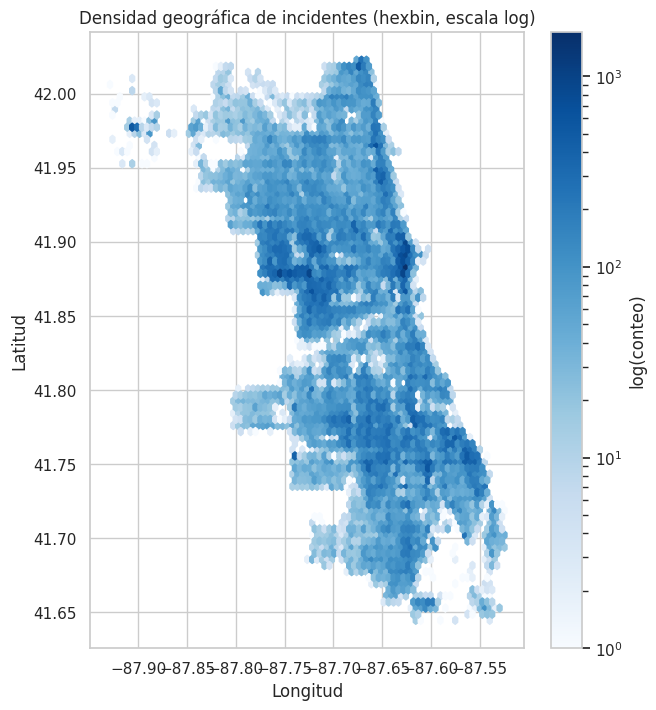

In [ ]:
# 2.6 Distribución geográfica (hexbin)
df_geo = df.dropna(subset=["latitude", "longitude"])
plt.figure(figsize=(7, 8))
plt.hexbin(
    df_geo["longitude"], df_geo["latitude"],
    gridsize=80, bins="log", cmap="Blues", mincnt=1
)
plt.colorbar(label="log(conteo)")
plt.title("Densidad geográfica de incidentes (hexbin, escala log)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig("figs/06_hexbin_geografico.png", dpi=150, bbox_inches="tight")
plt.show()

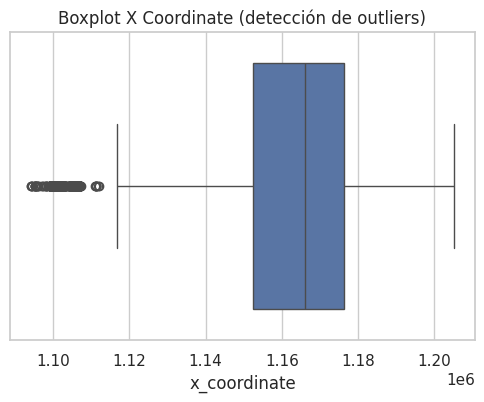

In [ ]:
# 2.7 Outliers en variables numéricas continuas
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["x_coordinate"].dropna())
plt.title("Boxplot X Coordinate (detección de outliers)")
plt.savefig("figs/07_boxplot_x_coordinate.png", dpi=150, bbox_inches="tight")
plt.show()

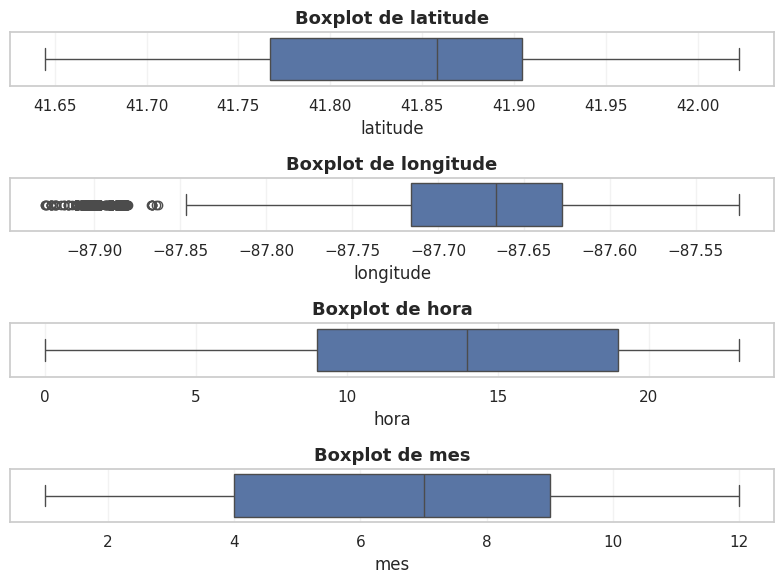

In [ ]:

fig, axes = plt.subplots(
    len(variables_numericas),
    1,
    figsize=(8, 6)
)

for i, columna in enumerate(variables_numericas):

    # Seleccionamos el eje correspondiente
    ax = axes[i]

    # Boxplot
    sns.boxplot(
        data=df,
        x=columna,
        ax=ax
    )

    # Título
    ax.set_title(
        f'Boxplot de {columna}',
        fontsize=13,
        fontweight='bold'
    )

    # Etiqueta del eje
    ax.set_xlabel(columna)

    # Cuadrícula
    ax.grid(
        axis='x',
        alpha=0.25
    )

plt.tight_layout()
plt.show()

## 3. Definición del problema de ML supervisado

- **Tipo de problema:** Clasificación binaria
- **Variable target:** `arrest` (`True`/`False` → hubo o no arresto en el incidente)
- **Features candidatas:** `primary_type`, `location_description`, `district`, `ward`, `community_area`, `domestic`, hora, día de la semana, mes, `latitude`/`longitude`
- **Motivación:** es un problema con relevancia operativa (asignación de recursos policiales) y tiene buena riqueza de features categóricas, geográficas y temporales para aplicar todas las técnicas pedidas en la consigna (encoding, discretización, balance de clases, PCA).

## 4. Preprocesamiento y limpieza

Eliminamos columnas irrelevantes para el modelado (IDs, texto libre, coordenadas redundantes con lat/lon), hacemos el split train/test **antes** de imputar o escalar (para evitar data leakage), tratamos faltantes y outliers.

In [ ]:
'''cols_a_eliminar = [
    "id", "case_number", "block", "description", "updated_on",
    "x_coordinate", "y_coordinate", "location", "iucr",
]'''
cols_a_eliminar = [
    "id", "case_number", "block", "description", "updated_on",
    "x_coordinate", "y_coordinate", "location", "iucr", "fbi_code",
]
df_model = df.drop(columns=[c for c in cols_a_eliminar if c in df.columns])

df_model["arrest"] = df_model["arrest"].astype(bool).astype(int)
df_model["domestic"] = df_model["domestic"].astype(bool).astype(int)

X = df_model.drop(columns=["arrest"])
y = df_model["arrest"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (211924, 13) | Test: (52981, 13)


In [ ]:
# Tratamiento de valores faltantes
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
imputer_num = SimpleImputer(strategy="median")
X_train[num_cols] = imputer_num.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer_num.transform(X_test[num_cols])

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    X_train[c] = X_train[c].fillna("desconocido")
    X_test[c] = X_test[c].fillna("desconocido")

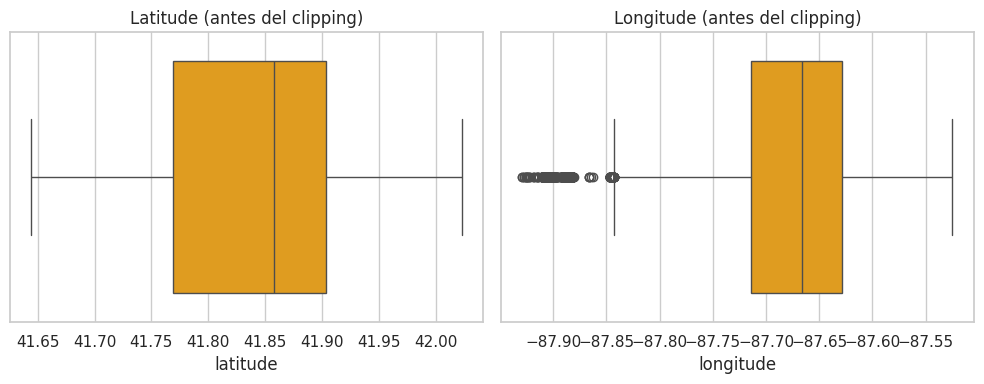

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=X_train["latitude"], ax=axes[0], color="orange")
axes[0].set_title("Latitude (antes del clipping)")
sns.boxplot(x=X_train["longitude"], ax=axes[1], color="orange")
axes[1].set_title("Longitude (antes del clipping)")
plt.tight_layout()
plt.savefig("figs/07a_boxplot_lat_lon_antes.png", dpi=150, bbox_inches="tight")
plt.show()

Con esta celda se intenta verificar si los incidentes reportados como outliers corresponden una zona alejada de la ciudad, como por ejemplo el aeropuerto.

In [ ]:
outliers_lon = X_train[X_train["longitude"] < X_train["longitude"].quantile(0.25) - 1.5 * (X_train["longitude"].quantile(0.75) - X_train["longitude"].quantile(0.25))]
outliers_lon["location_description"].value_counts().head(10)

,count
location_description,
AIRPORT TERMINAL UPPER LEVEL - SECURE AREA,246
AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA,157
AIRPORT VENDING ESTABLISHMENT,113
AIRCRAFT,57
AIRPORT PARKING LOT,56
AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA,51
AIRPORT TERMINAL LOWER LEVEL - SECURE AREA,43
AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,40
AIRPORT EXTERIOR - NON-SECURE AREA,32


Se confirma de que efectivamente son incidentes correspondientes a la zona del aeropuerto. Se los elimina porque eso pide el enunciado.

In [ ]:
# Detección y tratamiento de outliers (IQR) en variables geográficas
def marcar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (serie < lim_inf) | (serie > lim_sup)

for c in ["latitude", "longitude"]:
    if c in X_train.columns:
        mask_out = marcar_outliers_iqr(X_train[c])
        print(f"Outliers detectados en {c}: {mask_out.sum()} ({mask_out.mean()*100:.2f}%)")
        q1, q3 = X_train[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        X_train[c] = X_train[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        X_test[c] = X_test[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

Outliers detectados en latitude: 0 (0.00%)
Outliers detectados en longitude: 1053 (0.50%)


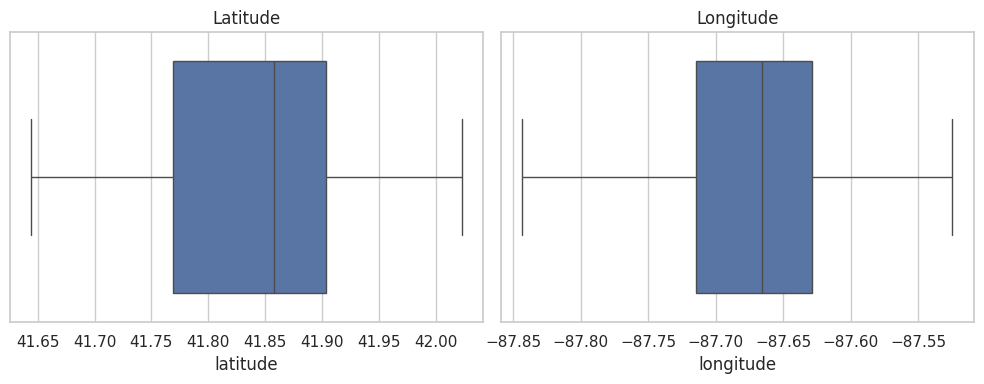

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=X_train["latitude"], ax=axes[0])
axes[0].set_title("Latitude")
sns.boxplot(x=X_train["longitude"], ax=axes[1])
axes[1].set_title("Longitude")
plt.tight_layout()
plt.savefig("figs/07b_boxplot_lat_lon.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature engineering

Creamos variables temporales a partir de `date`, discretizamos la hora en franjas horarias, agrupamos categorías poco frecuentes antes de codificar (clave para `primary_type` y `location_description`, de alta cardinalidad), y escalamos las numéricas.

In [ ]:
def feature_engineering_temporal(X, date_col_source):
    X = X.copy()
    X["hora"] = date_col_source.dt.hour
    X["dia_semana"] = date_col_source.dt.dayofweek  # 0=lunes
    X["mes"] = date_col_source.dt.month
    X["es_fin_de_semana"] = X["dia_semana"].isin([5, 6]).astype(int)
    # Discretización de la hora en franjas horarias: la hora puntual es ruidosa,
    # la franja captura mejor el patrón
    bins = [-1, 5, 11, 17, 21, 24]
    labels = ["madrugada", "mañana", "tarde", "noche", "noche_tardia"]
    X["franja_horaria"] = pd.cut(X["hora"], bins=bins, labels=labels)
    return X.drop(columns=["date"], errors="ignore")

date_train = df.loc[X_train.index, "date"]
date_test = df.loc[X_test.index, "date"]

X_train = feature_engineering_temporal(X_train, date_train)
X_test = feature_engineering_temporal(X_test, date_test)

In [ ]:
# Encoding: agrupamos categorías raras en "otros" antes del one-hot
def agrupar_categorias_raras(serie, umbral=0.01):
    frecuencias = serie.value_counts(normalize=True)
    categorias_frecuentes = frecuencias[frecuencias >= umbral].index
    return serie.where(serie.isin(categorias_frecuentes), other="otros")

for c in ["primary_type", "location_description", "fbi_code"]:
    if c in X_train.columns:
        X_train[c] = agrupar_categorias_raras(X_train[c])
        X_test[c] = X_test[c].where(X_test[c].isin(X_train[c].unique()), other="otros")

cat_cols_final = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols_final]),
    columns=encoder.get_feature_names_out(cat_cols_final),
    index=X_train.index,
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols_final]),
    columns=encoder.get_feature_names_out(cat_cols_final),
    index=X_test.index,
)

num_cols_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_train_final = pd.concat([X_train[num_cols_final], X_train_cat], axis=1)
X_test_final = pd.concat([X_test[num_cols_final], X_test_cat], axis=1)

In [ ]:
# Escalado de features numéricas
scaler = StandardScaler()
X_train_final[num_cols_final] = scaler.fit_transform(X_train_final[num_cols_final])
X_test_final[num_cols_final] = scaler.transform(X_test_final[num_cols_final])

print(f"Shape final features -> Train: {X_train_final.shape}, Test: {X_test_final.shape}")

Shape final features -> Train: (211924, 44), Test: (52981, 44)


In [ ]:
# Balance de clases
print("Balance de clases en train:")
print(y_train.value_counts(normalize=True))

Balance de clases en train:
arrest
0   0.74
1   0.26
Name: proportion, dtype: float64


In [ ]:
# Aplicamos SMOTE para balancear la clase minoritaria (arrest=1) en el set de entrenamiento
# IMPORTANTE: se aplica solo sobre train, nunca sobre test, para no filtrar información
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train)

print("Balance de clases en train (DESPUÉS de SMOTE):")
print(y_train_bal.value_counts(normalize=True))
print(y_train_bal.value_counts())

filas_sinteticas = (y_train_bal == 1).sum() - (y_train == 1).sum()
print(f"\nFilas sintéticas generadas para la clase minoritaria (arrest=1): {filas_sinteticas:,}")
print(f"Tamaño de train: {len(y_train):,} -> {len(y_train_bal):,} filas")

Balance de clases en train (DESPUÉS de SMOTE):
arrest
0   0.50
1   0.50
Name: proportion, dtype: float64
arrest
0    155858
1    155858
Name: count, dtype: int64

Filas sintéticas generadas para la clase minoritaria (arrest=1): 99,792
Tamaño de train: 211,924 -> 311,716 filas


## 6. Reducción de dimensionalidad

Comparamos dos enfoques: selección de features (correlación + mutual information) y extracción de features (PCA).

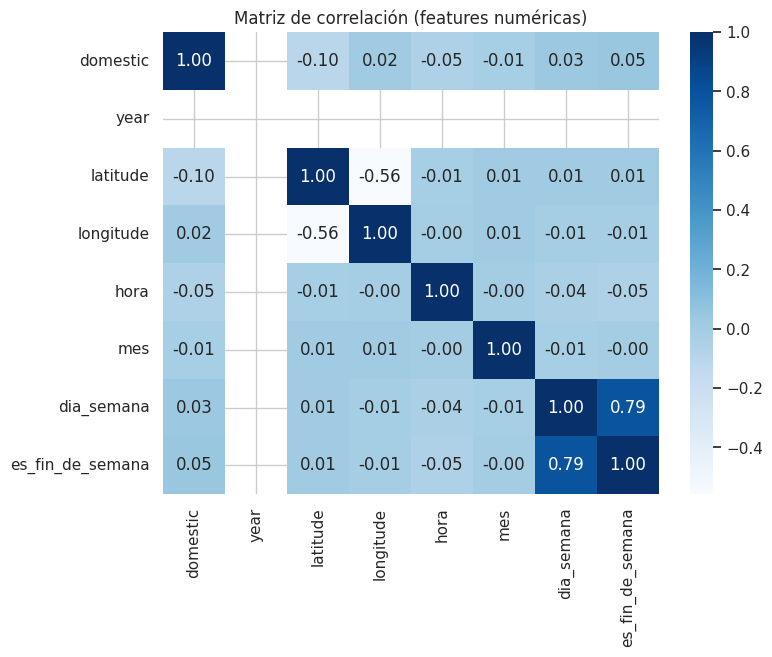

In [ ]:
# 6.1 Matriz de correlación
corr_matrix = X_train_final[num_cols_final].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlación (features numéricas)")
plt.savefig("figs/08_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

Top 15 features por mutual information con el target:
primary_type_NARCOTICS            0.13
latitude                          0.06
longitude                         0.06
primary_type_THEFT                0.02
primary_type_CRIMINAL DAMAGE      0.02
es_fin_de_semana                  0.02
location_description_SIDEWALK     0.01
domestic                          0.01
primary_type_CRIMINAL TRESPASS    0.01
primary_type_DECEPTIVE PRACTICE   0.01
franja_horaria_tarde              0.01
location_description_RESIDENCE    0.01
hora                              0.01
primary_type_WEAPONS VIOLATION    0.01
primary_type_BURGLARY             0.01
dtype: float64


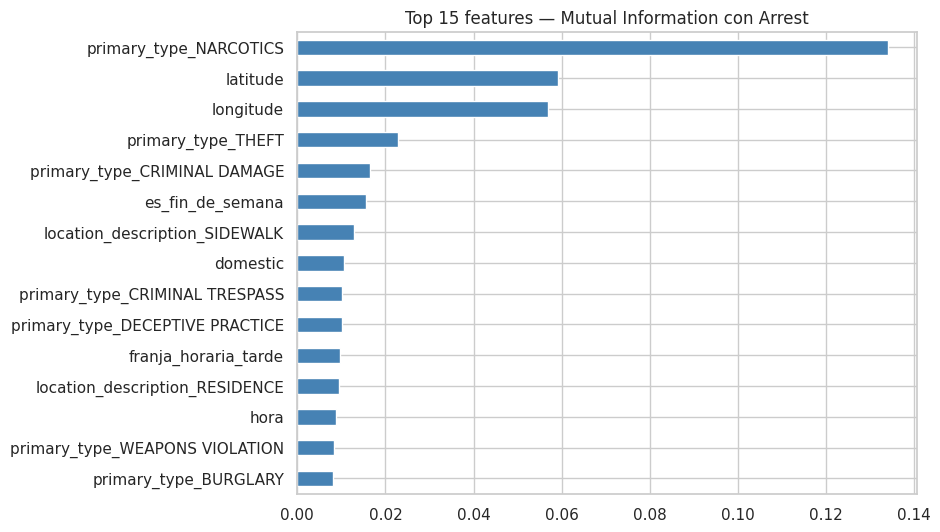

In [ ]:
# 6.1 Mutual information con el target
mi_scores = mutual_info_classif(X_train_final, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train_final.columns).sort_values(ascending=False)
print("Top 15 features por mutual information con el target:")
print(mi_series.head(15))

plt.figure(figsize=(8, 6))
mi_series.head(15).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 features — Mutual Information con Arrest")
plt.savefig("figs/09_mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

PCA: 15 componentes explican el 90% de la varianza (de 44 features originales)


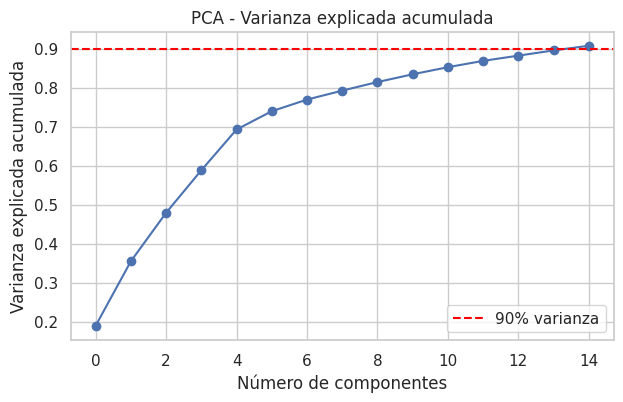

In [ ]:
# 6.2 PCA
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)  # conserva 90% de varianza
X_train_pca = pca.fit_transform(X_train_final)
print(f"PCA: {pca.n_components_} componentes explican el 90% de la varianza "
      f"(de {X_train_final.shape[1]} features originales)")

plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% varianza")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.legend()
plt.savefig("figs/10_pca_varianza_explicada.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Ver qué features originales pesan más en los primeros componentes
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train_final.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Top 10 features que más pesan en el primer componente (valor absoluto)
print("Top features en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

print("\nTop features en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(10))

Top features en PC1:
es_fin_de_semana           0.70
dia_semana                 0.70
hora                       0.10
domestic                   0.09
franja_horaria_madrugada   0.05
primary_type_BATTERY       0.03
latitude                   0.02
longitude                  0.02
franja_horaria_tarde       0.02
franja_horaria_noche       0.02
Name: PC1, dtype: float64

Top features en PC2:
latitude                         0.70
longitude                        0.69
domestic                         0.18
primary_type_BATTERY             0.04
location_description_RESIDENCE   0.03
primary_type_THEFT               0.02
location_description_APARTMENT   0.02
hora                             0.02
primary_type_NARCOTICS           0.02
location_description_otros       0.01
Name: PC2, dtype: float64


**Ventajas / desventajas de PCA en este caso:**

- (+) Reduce fuertemente la dimensionalidad, útil dado el one-hot de alta cardinalidad (`primary_type`, `location_description`).
- (+) Elimina colinealidad entre features numéricas.
- (−) Pierde interpretabilidad directa: los componentes ya no son "primary_type = Theft".
- (−) Con features mayormente categóricas one-hot, PCA suele ser subóptimo frente a una selección basada en mutual information — comparar los resultados obtenidos arriba y concluir cuál conviene para este dataset.